# 04 - 3D 场诊断

查看模型在 3D 空间中到底预测了什么——不经过体渲染投影，直接看 density/visibility 场。

In [7]:
import sys, os, glob
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, IntSlider, FloatSlider
from IPython.display import display, clear_output
import ipywidgets as widgets

%matplotlib inline

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

CUDA_DEVICE = 0
os.environ['CUDA_VISIBLE_DEVICES'] = str(CUDA_DEVICE)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. 加载模型和数据

In [8]:
from src.models.model_mstnf import MSTNFModel
from src.data.dataset import SoftSequenceDataset

# ── 配置 ──
LOG_DIR = os.path.join(PROJECT_ROOT, 'train_log', 'train_mstnf', 'exp_20260423_01')
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'sequence_data')
WEIGHT_FILE = 'best_model.pt'  # 或改成 'model_05000.pt' 等查看不同阶段

# 加载归一化系数
norm_path = os.path.join(LOG_DIR, 'action_norm_factor.txt')
norm_factor = float(np.loadtxt(norm_path)) if os.path.exists(norm_path) else 1.0
print(f'Norm factor: {norm_factor}')

# 加载测试数据
seq_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.npz')))
val_file = seq_files[-1]
val_ds = SoftSequenceDataset(DATA_DIR, seq_len=20, file_list=[val_file], norm_factor=norm_factor)
print(f'数据: {os.path.basename(val_file)}, {len(val_ds)} 帧')

# 加载模型
action_dim = val_ds.action_dim
model = MSTNFModel(action_dim=action_dim, window_size=20, n_scales=4, hidden_dim=128).to(device)
weight_path = os.path.join(LOG_DIR, 'model', WEIGHT_FILE)
model.load_state_dict(torch.load(weight_path, map_location=device))
model.eval()
print(f'模型: {weight_path}')

# 学到的衰减率
decays = model.get_learned_decays()
print(f'学到的衰减率: {[f"{d:.3f}" for d in decays]}')

Norm factor: 1.0
数据: seq_3_1776933174.npz, 500 帧


FileNotFoundError: [Errno 2] No such file or directory: '/Data5/ddf/projects/SelfSoftRobot/train_log/train_mstnf/exp_20260423_01/model/best_model.pt'

## 2. 构建 3D 查询网格

In [ ]:
GRID_RES = 40
x = np.linspace(-0.3, 0.3, GRID_RES)
y = np.linspace(-0.3, 0.3, GRID_RES)
z = np.linspace(0.0, 0.55, GRID_RES)

gx, gy, gz = np.meshgrid(x, y, z, indexing='ij')
grid_points = np.stack([gx.flatten(), gy.flatten(), gz.flatten()], axis=-1)
grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)
print(f'查询网格: {GRID_RES}^3 = {len(grid_points)} 个点')

查询网格: 40^3 = 64000 个点


## 3. 查询模型并可视化 3D 点云

对选定帧，查询 3D 网格中每个点的 (visibility, density)，筛选出高密度点画成 3D 散点图。

In [ ]:
def query_3d_field(frame_idx, threshold=0.5):
    """查询指定帧的 3D 场，返回过滤后的点云和原始 density/visibility。"""
    action_window, _ = val_ds[frame_idx]
    action_window = action_window.unsqueeze(0).to(device)  # (1, 20, D)
    
    with torch.no_grad():
        physics_state = model.encode_temporal(action_window)  # (1, Hidden)
        state_expanded = physics_state.expand(grid_tensor.shape[0], -1)  # (N_pts, Hidden)
        
        # 分块查询
        chunk = 8192
        raw_parts = []
        for i in range(0, len(grid_tensor), chunk):
            pts = grid_tensor[i:i+chunk].unsqueeze(1)  # (chunk, 1, 3)
            states = state_expanded[i:i+chunk]
            raw_parts.append(model.decode_spatial(pts, states))
        
        raw = torch.cat(raw_parts, dim=0).squeeze(1)  # (N_pts, 2)
    
    visibility = raw[:, 0].cpu().numpy()
    density = raw[:, 1].cpu().numpy()
    
    # 通过 density 阈值筛选
    alpha = 1.0 - np.exp(-np.maximum(density, 0))
    mask = alpha > threshold
    
    return grid_points, visibility, density, alpha, mask

def show_3d_diagnosis(frame_idx, threshold):
    pts, vis, dens, alpha, mask = query_3d_field(frame_idx, threshold)
    n_valid = mask.sum()
    
    fig = plt.figure(figsize=(18, 5))
    
    # ── 左: 3D 点云 ──
    ax1 = fig.add_subplot(131, projection='3d')
    if n_valid > 0:
        valid_pts = pts[mask]
        valid_alpha = alpha[mask]
        # 颜色 = alpha 值，越亮表示密度越高
        sc = ax1.scatter(valid_pts[:, 0], valid_pts[:, 1], valid_pts[:, 2],
                         c=valid_alpha, cmap='hot', s=3, alpha=0.6, vmin=0, vmax=1)
        plt.colorbar(sc, ax=ax1, shrink=0.5, label='Alpha')
    ax1.set_xlim(-0.3, 0.3); ax1.set_ylim(-0.3, 0.3); ax1.set_zlim(0, 0.55)
    ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
    ax1.set_title(f'3D Density Field ({n_valid} pts, thr={threshold:.2f})')
    
    # ── 中: density 直方图 ──
    ax2 = fig.add_subplot(132)
    ax2.hist(alpha, bins=100, edgecolor='none')
    ax2.axvline(x=threshold, color='r', linestyle='--', label=f'threshold={threshold:.2f}')
    ax2.set_title('Alpha Distribution')
    ax2.set_xlabel('Alpha = 1 - exp(-relu(density))')
    ax2.set_ylabel('Count')
    ax2.legend()
    ax2.set_yscale('log')
    
    # ── 右: GT 图像 ──
    ax3 = fig.add_subplot(133)
    _, gt_img = val_ds[frame_idx]
    H, W = val_ds.H, val_ds.W
    ax3.imshow(gt_img.reshape(H, W), cmap='gray', vmin=0, vmax=1)
    ax3.set_title(f'GT Image (Frame {frame_idx})')
    ax3.axis('off')
    
    plt.tight_layout()
    plt.show()
    print(f'Frame {frame_idx}: {n_valid}/{len(pts)} points above threshold')
    print(f'  alpha range: [{alpha.min():.4f}, {alpha.max():.4f}]')
    print(f'  density range: [{dens.min():.4f}, {dens.max():.4f}]')
    print(f'  visibility range: [{vis.min():.4f}, {vis.max():.4f}]')

# 交互式浏览
frame_slider = widgets.IntSlider(min=0, max=len(val_ds)-1, value=0, description='Frame')
thr_slider = widgets.FloatSlider(min=0.01, max=0.95, step=0.01, value=0.3, description='Threshold')
out = widgets.Output()

def on_change(change):
   with out:
        clear_output(wait=True)
        show_3d_diagnosis(frame_slider.value, thr_slider.value)

frame_slider.observe(on_change, names='value')
thr_slider.observe(on_change, names='value')
display(widgets.VBox([frame_slider, thr_slider, out]))
on_change(None)

## 4. 多帧对比：不同动作下的 3D 场形状

/tmp/ipykernel_1983091/3913227836.py:20: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


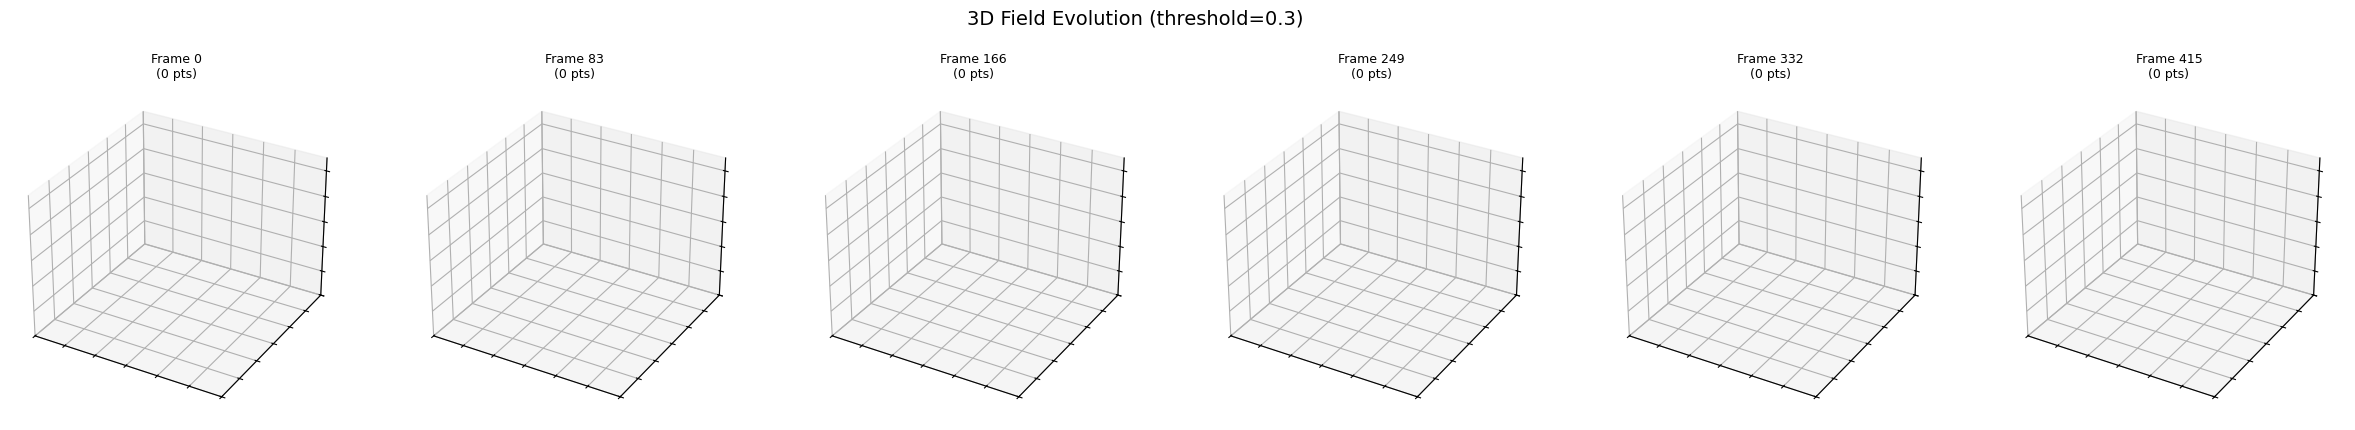

In [ ]:
N_SHOW = 6
step = max(1, len(val_ds) // N_SHOW)
frame_indices = list(range(0, len(val_ds), step))[:N_SHOW]
THRESHOLD = 0.3

fig = plt.figure(figsize=(5 * N_SHOW, 5))

for col, fi in enumerate(frame_indices):
    pts, vis, dens, alpha, mask = query_3d_field(fi, THRESHOLD)
    
    ax = fig.add_subplot(1, N_SHOW, col + 1, projection='3d')
    if mask.sum() > 0:
        valid = pts[mask]
        ax.scatter(valid[:, 0], valid[:, 1], valid[:, 2], c='r', s=2, alpha=0.5)
    ax.set_xlim(-0.3, 0.3); ax.set_ylim(-0.3, 0.3); ax.set_zlim(0, 0.55)
    ax.set_title(f'Frame {fi}\n({mask.sum()} pts)', fontsize=9)
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])

plt.suptitle(f'3D Field Evolution (threshold={THRESHOLD})', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Density 切片查看（固定 Z 平面）

在 Z=0.25（杆体中部高度）处切一刀，看该平面的 density 分布热力图。

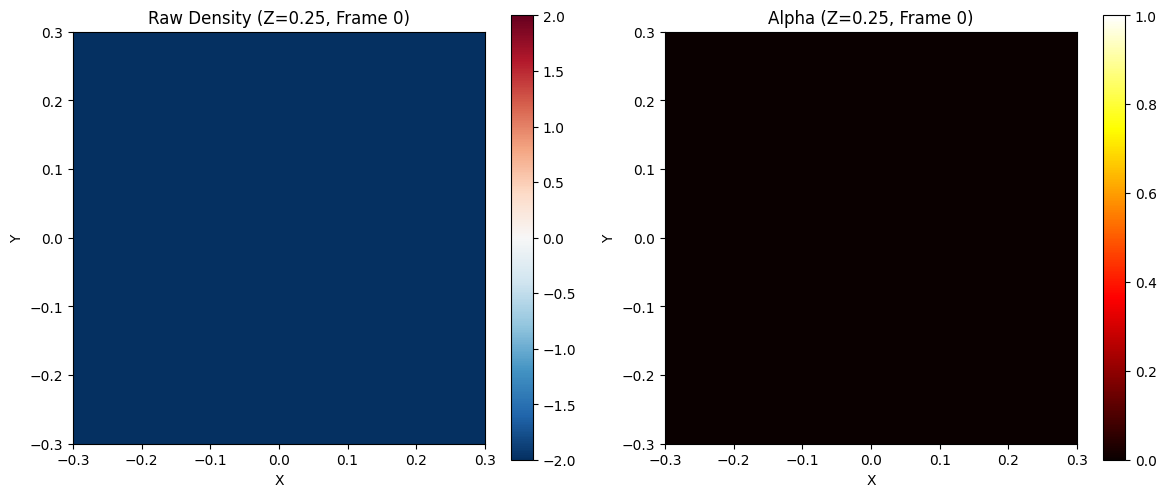

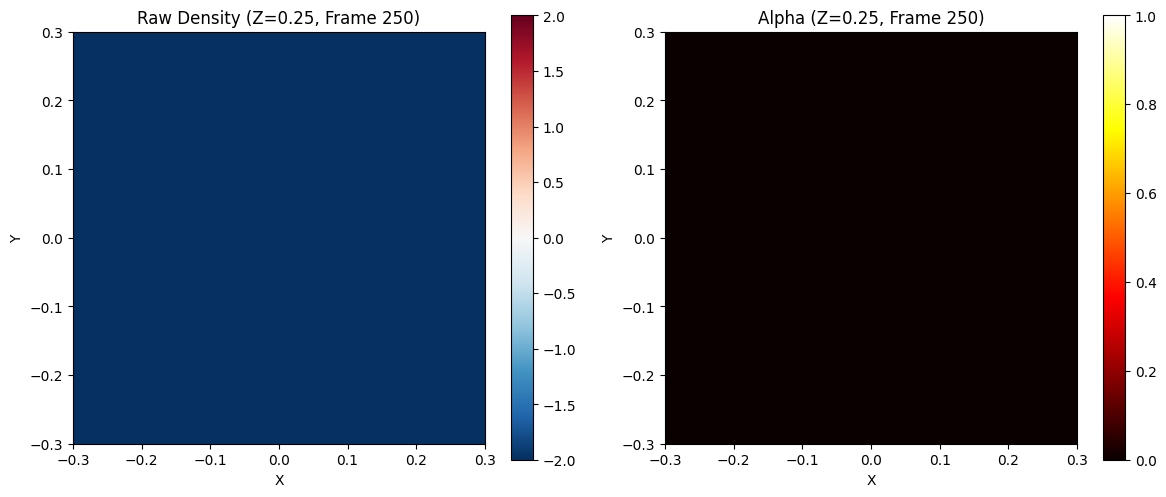

In [ ]:
def show_density_slice(frame_idx, z_level=0.25):
    """在指定 Z 高度切一片 density 热力图。"""
    # 构建单层查询网格
    nx, ny = 60, 60
    xs = np.linspace(-0.3, 0.3, nx)
    ys = np.linspace(-0.3, 0.3, ny)
    gxx, gyy = np.meshgrid(xs, ys)
    slice_pts = np.stack([gxx.flatten(), gyy.flatten(),
                          np.full(nx*ny, z_level)], axis=-1)
    slice_tensor = torch.tensor(slice_pts, dtype=torch.float32, device=device)
    
    action_window, _ = val_ds[frame_idx]
    action_window = action_window.unsqueeze(0).to(device)
    
    with torch.no_grad():
        state = model.encode_temporal(action_window)
        state_exp = state.expand(len(slice_tensor), -1)
        raw = model.decode_spatial(slice_tensor.unsqueeze(1), state_exp).squeeze(1)
    
    density = raw[:, 1].cpu().numpy().reshape(ny, nx)
    alpha = 1.0 - np.exp(-np.maximum(density, 0))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    im1 = ax1.imshow(density, extent=[-0.3, 0.3, -0.3, 0.3], cmap='RdBu_r',
                     origin='lower', vmin=-2, vmax=2)
    ax1.set_title(f'Raw Density (Z={z_level:.2f}, Frame {frame_idx})')
    ax1.set_xlabel('X'); ax1.set_ylabel('Y')
    plt.colorbar(im1, ax=ax1)
    
    im2 = ax2.imshow(alpha, extent=[-0.3, 0.3, -0.3, 0.3], cmap='hot',
                     origin='lower', vmin=0, vmax=1)
    ax2.set_title(f'Alpha (Z={z_level:.2f}, Frame {frame_idx})')
    ax2.set_xlabel('X'); ax2.set_ylabel('Y')
    plt.colorbar(im2, ax=ax2)
    
    plt.tight_layout()
    plt.show()

show_density_slice(0, z_level=0.25)
show_density_slice(len(val_ds)//2, z_level=0.25)